<a href="https://colab.research.google.com/github/Rbca0/Data-Science/blob/main/Unit8/Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

A decision tree is a set of nodes that define the domains for a bunch of horizantal lines (they are the predicted the psuedo mean line). The first layer of the tree would split the data into two horizantal lines. The second layer would split the data into 3 layers, each filtering the data into wither "true" or "false".

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth is how many layers of >= or <= there are in th tree. Your tree is too deep if there the mean line seems to jump around to outliers or single points. It's not deep enough if the residuuals are very high.

**Task4:**

How are BART models similar and different from a decision tree?

Bart models are a bunch of weird decision trees summed togehther (weightedly). They are similar in that nodes are added as tree depth is increased, but different in that a Bart model has many trees and uses randomness to vary them. A Bart model will purposefully build different trees by varying based on the residuals and then sum them. Bart models are also shallow (msmaller depth) compared to a decision rtree which will generally have more layers to be more percise.

**Task5**:

Why would we use a BART model instead of a decision tree?

When you don't understand the interactions you should use a Bart model because you can visualize the interactions easily. they are also more complicated.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [5]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

In [8]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [24]:
X = penguins[['flipper_length', 'bill_depth', 'bill_length']]
Y = penguins['body_mass']
##gemini did syntax of 1st 2 lines
with pm.Model() as model_penguins:
    s = pm.HalfNormal('s',1000)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y)
    idata_penguins = pm.sample(compute_convergence_checks=False)

Output()

In [25]:
pm.sample_posterior_predictive(idata_penguins,model_penguins, extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

<Axes: xlabel='y'>

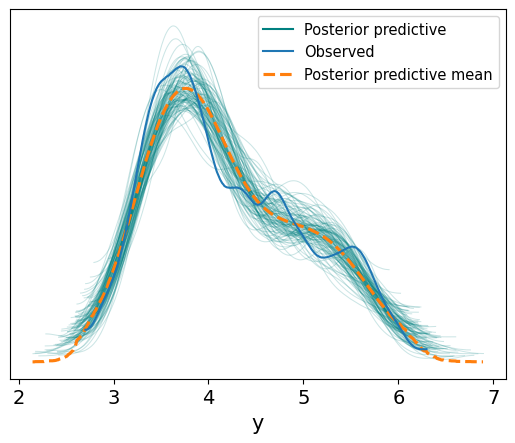

In [26]:
az.plot_ppc(idata_penguins, num_pp_samples=100, colors=["teal", "C0", "C1"])

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [27]:
posterior_mean = idata_penguins.posterior["μ"]

μ_hdi = az.hdi(ary=idata_penguins, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_penguins, group="posterior_predictive", var_names=["y"]
).T

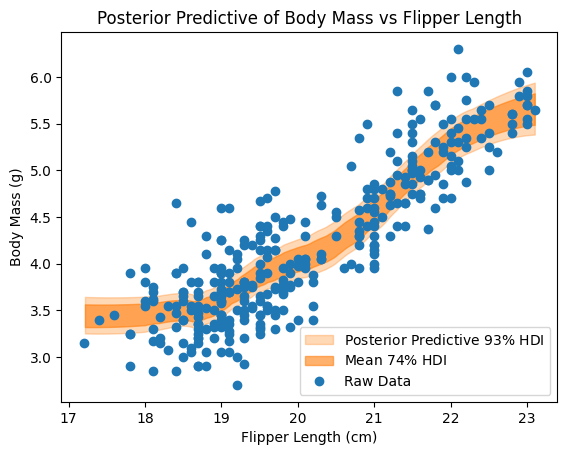

In [36]:
x_plot = X['flipper_length']

# Get indices to sort the data by flipper_length for smoother plots
idx = np.argsort(x_plot.values)

fig, ax = plt.subplots()

az.plot_hdi(
    x=x_plot.iloc[idx],
    y=posterior_mean[:, :, idx], # Sort samples by the same index

    # y=posterior_mean[idx, :], # Sort samples by the same index
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior Predictive $93\%$ HDI"},
)

# For posterior_mean, it's (chain, draw, obs_idx), so sort the obs_idx dimension
az.plot_hdi(
    x=x_plot.iloc[idx],
    y=posterior_mean[:, :, idx],
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)

# Plot the raw data (flipper length vs body mass)
ax.plot(penguins['flipper_length'], penguins['body_mass'], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive of Body Mass vs Flipper Length",
    xlabel="Flipper Length (cm)",
    ylabel="Body Mass (g)"
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

No, because I think there are ffactors not being considered enough, like species. The posterior predictive curve is bimodal, and I think a hierarchy would capture the trend better.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.